In [1]:
from qiskit_gym.envs import LinearFunctionGym, CliffordGym, PermutationGym, LinearFunctionNoisyGym
from qiskit_gym.rl import RLSynthesis, PPOConfig, AlphaZeroConfig, BasicPolicyConfig


from qiskit import QuantumCircuit
from qiskit.transpiler import CouplingMap
import numpy as np

# Training RL

In [2]:

cmap_6_line = CouplingMap.from_ring(6, bidirectional=True)
env = LinearFunctionNoisyGym.from_coupling_map(cmap_6_line, basis_gates=["CX", 'SWAP'])
env2 = LinearFunctionGym.from_coupling_map(cmap_6_line, basis_gates= ['CX', 'SWAP'])

noisy_rl = RLSynthesis(env, PPOConfig(), BasicPolicyConfig())
noisy_rl.learn(initial_difficulty=3, num_iterations=10, tb_path="runs/lf_4_line_ppo/")  # This will track progress in Tensorboard

noiseless_rl = RLSynthesis(env2, PPOConfig(), BasicPolicyConfig())
noiseless_rl.learn(num_iterations=10, tb_path="runs/lf_4_line_ppo/")  # This will track progress in Tensorboard

2026-02-04 02:11:06.869 | INFO     | twisterl.rl.algorithm:learn:177 - (3/0) {'successes': {'ppo_deterministic': 0.009999999776482582, 'ppo_10': 0.14000000059604645}, 'rewards': {'ppo_deterministic': -0.901074230670929, 'ppo_10': -0.3601367175579071}, 'difficulty': 3, 'success': 0.009999999776482582, 'reward': -0.901074230670929} | {'to_rust': 0.005306833, 'eval_ppo_deterministic': 0.0025535, 'eval_ppo_10': 0.026317209, 'collect': 0.034654583, 'data_to_torch': 0.057931667, 'train': 0.432418209, 'total': 0.559619542}
2026-02-04 02:11:07.272 | INFO     | twisterl.rl.algorithm:learn:177 - (3/1) {'successes': {'ppo_deterministic': 0.009999999776482582, 'ppo_10': 0.07999999821186066}, 'rewards': {'ppo_deterministic': -1.3749727010726929, 'ppo_10': -0.4589804708957672}, 'difficulty': 3, 'success': 0.009999999776482582, 'reward': -1.3749727010726929} | {'to_rust': 0.006391875, 'eval_ppo_deterministic': 0.004336167, 'eval_ppo_10': 0.028430334, 'collect': 0.033794792, 'data_to_torch': 0.0281767

In [3]:
noisy_rl.env.config['gateset']

[('CX', (0, 1)),
 ('CX', (0, 5)),
 ('CX', (1, 0)),
 ('CX', (1, 2)),
 ('CX', (2, 1)),
 ('CX', (2, 3)),
 ('CX', (3, 2)),
 ('CX', (3, 4)),
 ('CX', (4, 3)),
 ('CX', (4, 5)),
 ('CX', (5, 0)),
 ('CX', (5, 4)),
 ('SWAP', (0, 1)),
 ('SWAP', (0, 5)),
 ('SWAP', (1, 0)),
 ('SWAP', (1, 2)),
 ('SWAP', (2, 1)),
 ('SWAP', (2, 3)),
 ('SWAP', (3, 2)),
 ('SWAP', (3, 4)),
 ('SWAP', (4, 3)),
 ('SWAP', (4, 5)),
 ('SWAP', (5, 0)),
 ('SWAP', (5, 4))]

# Generating Random Circuit

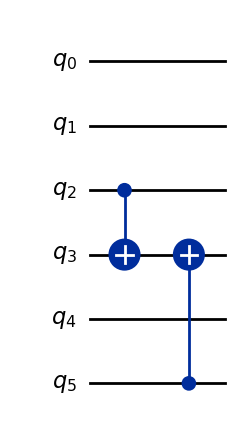

In [4]:
#generating a random quantum circuit

import random

def generate_random_circ(num_qubits):
    qc = QuantumCircuit(num_qubits)
    for i in range(random.randrange(2, 3)):
        q1 = random.randint(0, num_qubits - 1)
        q2 = q1 + (2 * random.randint(-1, 1)) 
        if q1 == q2 :
            q2 = q1 + 1
        if  q2 >= num_qubits:
            q2 = q1 - 2
        qc.cx(q1,q2)

    return qc

qc = generate_random_circ(6)
qc.draw(fold=-1, output="mpl")


# Testing No Noise Added Prior

Noisy Synthesis


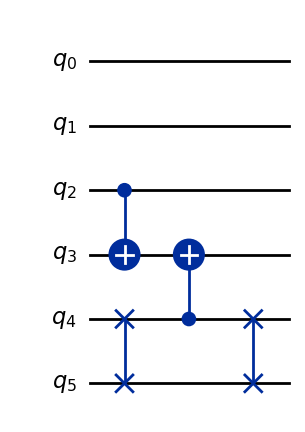

In [5]:
print('Noisy Synthesis')
qc_lf_output = noisy_rl.synth(qc, num_searches=10000, num_mcts_searches=0, deterministic=False)
qc_lf_output.draw(fold=-1, output ='mpl',)

Noiseless Synthesis


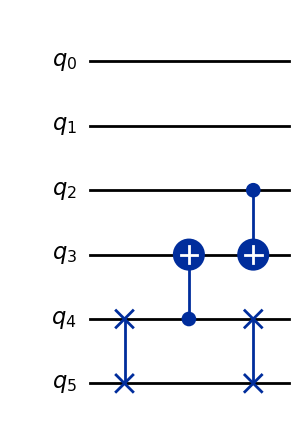

In [ ]:
print('Noiseless Synthesis')
qc_lf_output = noiseless_rl.synth(qc, num_searches=10000, num_mcts_searches=0, deterministic=False)
qc_lf_output.draw(fold=-1, output ='mpl',)

## Testing Noise Crowded on 0,1 Edge

In [6]:
cmap_6_line = CouplingMap.from_ring(5, bidirectional=True)
env = LinearFunctionNoisyGym.from_coupling_map(cmap_6_line, basis_gates=["CX", 'SWAP'])
env2 = LinearFunctionGym.from_coupling_map(cmap_6_line, basis_gates= ['CX', 'SWAP'])

noisy_rl = RLSynthesis(env, PPOConfig(), BasicPolicyConfig())
noisy_rl.learn(initial_difficulty=3, num_iterations=10, tb_path="runs/lf_4_line_ppo/")  # This will track progress in Tensorboard

noiseless_rl = RLSynthesis(env2, PPOConfig(), BasicPolicyConfig())
noiseless_rl.learn(num_iterations=10, tb_path="runs/lf_4_line_ppo/")  # This will track progress in Tensorboard

2026-02-02 16:12:44.152 | INFO     | twisterl.rl.algorithm:learn:177 - (3/0) {'successes': {'ppo_deterministic': 0.019999999552965164, 'ppo_10': 0.17000000178813934}, 'rewards': {'ppo_deterministic': -0.8695352077484131, 'ppo_10': -0.31833595037460327}, 'difficulty': 3, 'success': 0.019999999552965164, 'reward': -0.8695352077484131} | {'to_rust': 0.003396833, 'eval_ppo_deterministic': 0.002786666, 'eval_ppo_10': 0.020170208, 'collect': 0.025166166, 'data_to_torch': 0.135886542, 'train': 0.259202125, 'total': 0.4470505}
2026-02-02 16:12:44.164 | INFO     | twisterl.rl.algorithm:learn:197 - (3/0) Improved, saved checkpoint!
2026-02-02 16:12:44.425 | INFO     | twisterl.rl.algorithm:learn:177 - (3/1) {'successes': {'ppo_deterministic': 0.05000000074505806, 'ppo_10': 0.07999999821186066}, 'rewards': {'ppo_deterministic': -0.8734335899353027, 'ppo_10': -0.4608789086341858}, 'difficulty': 3, 'success': 0.05000000074505806, 'reward': -0.8734335899353027} | {'to_rust': 0.00325325, 'eval_ppo_de

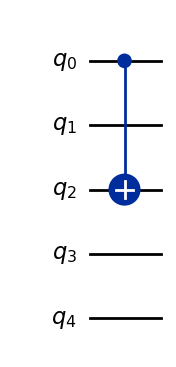

In [7]:

from qiskit.circuit.library.generalized_gates import LinearFunction
qc = QuantumCircuit(5)

qc.cx(0,2)

qc.draw(output = 'mpl')

Noisy Synthesis


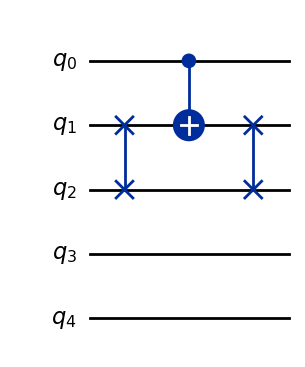

In [8]:
#Make sure to edit and add noise on 0,1 edge and rebuild 

print('Noisy Synthesis')
qc_lf_output = noisy_rl.synth(qc, num_searches=10000, num_mcts_searches=0, deterministic=False)
qc_lf_output.draw(fold=-1, output ='mpl',)

Noiseless Synthesis


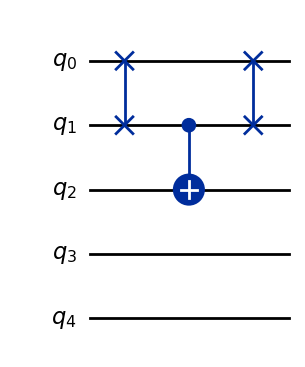

In [9]:
print('Noiseless Synthesis')
qc_lf_output = noiseless_rl.synth(qc, num_searches=10000, num_mcts_searches=0, deterministic=False)
qc_lf_output.draw(fold=-1, output ='mpl',)